In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [241]:
# 1. Load dataset
data = pd.read_csv("../data/titanic_clean.csv")
X = data.drop("Survived", axis=1)
y = data["Survived"]

In [242]:
# 2. Load trained models
rf = joblib.load("../models/random_forest_model.pkl")
gb = joblib.load("../models/gradient_boosting_model.pkl")

In [243]:
print(X.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'IsAlone']


In [244]:
# 3. Evaluate models
y_pred_rf = rf.predict(X)
y_prob_rf = rf.predict_proba(X)[:,1]

y_pred_gb = gb.predict(X)
y_prob_gb = gb.predict_proba(X)[:,1]

results = {
    "Random Forest": {
        "Accuracy": accuracy_score(y, y_pred_rf),
        "Precision": precision_score(y, y_pred_rf),
        "Recall": recall_score(y, y_pred_rf),
        "F1": f1_score(y, y_pred_rf),
        "ROC-AUC": roc_auc_score(y, y_prob_rf)
    },
    "Gradient Boosting": {
        "Accuracy": accuracy_score(y, y_pred_gb),
        "Precision": precision_score(y, y_pred_gb),
        "Recall": recall_score(y, y_pred_gb),
        "F1": f1_score(y, y_pred_gb),
        "ROC-AUC": roc_auc_score(y, y_prob_gb)
    }
}
print(pd.DataFrame(results).T)

                   Accuracy  Precision    Recall        F1   ROC-AUC
Random Forest      0.920314   0.941368  0.845029  0.890601  0.964095
Gradient Boosting  0.903479   0.918301  0.821637  0.867284  0.946905


c:\Users\S SISEENDRI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\S SISEENDRI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\S SISEENDRI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
c:\Users\S SISEENDRI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


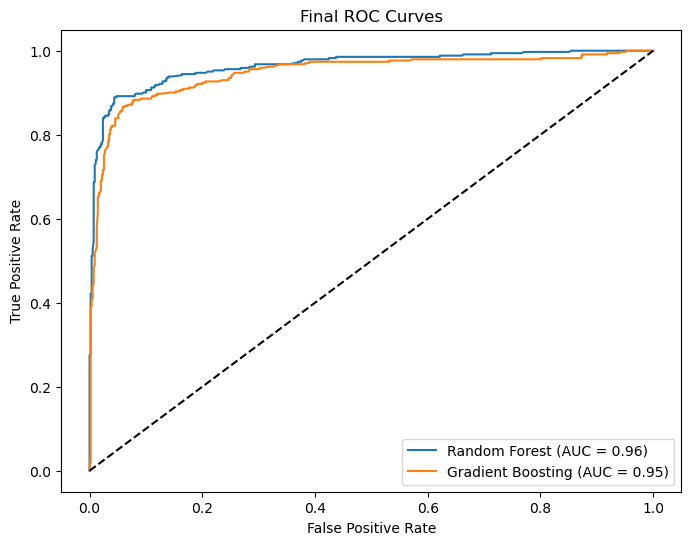

In [245]:
# 4. Plot ROC curves
plt.figure(figsize=(8,6))
fpr_rf, tpr_rf, _ = roc_curve(y, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y, y_prob_gb)

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {results['Random Forest']['ROC-AUC']:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {results['Gradient Boosting']['ROC-AUC']:.2f})")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curves")
plt.legend()
plt.show()

In [246]:
import joblib
model = joblib.load("../models/random_forest_model.pkl")

# Take one sample from test set
sample = X.iloc[0].values.reshape(1, -1)

# Predict
prediction = model.predict(sample)
print("Prediction:", prediction)


Prediction: [0]
